In [1]:
import polars as pl
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent 
df = pl.read_parquet(PROJECT_ROOT / "data/raw/20250811_bgg.parquet")

--- Statistics ---
shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ num_ratings │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 88465.0     │
│ null_count ┆ 0.0         │
│ mean       ┆ 270.804906  │
│ std        ┆ 2403.016603 │
│ min        ┆ 0.0         │
│ 25%        ┆ 1.0         │
│ 50%        ┆ 4.0         │
│ 75%        ┆ 30.0        │
│ max        ┆ 136203.0    │
└────────────┴─────────────┘

--- Percentiles for num_ratings ---
shape: (1, 4)
┌────────┬────────┬────────┬──────────────┐
│ 90th % ┆ 95th % ┆ 99th % ┆ Absolute Max │
│ ---    ┆ ---    ┆ ---    ┆ ---          │
│ f64    ┆ f64    ┆ f64    ┆ i64          │
╞════════╪════════╪════════╪══════════════╡
│ 199.0  ┆ 638.0  ┆ 5068.0 ┆ 136203       │
└────────┴────────┴────────┴──────────────┘

--- Most Common num_ratings ---
shape: (10, 2)
┌─────────────┬───────┐
│ num_ratings ┆ count │
│ ---         ┆ ---   │
│ i64         ┆ u32   │
╞═════════════╪═══════╡
│ 0  

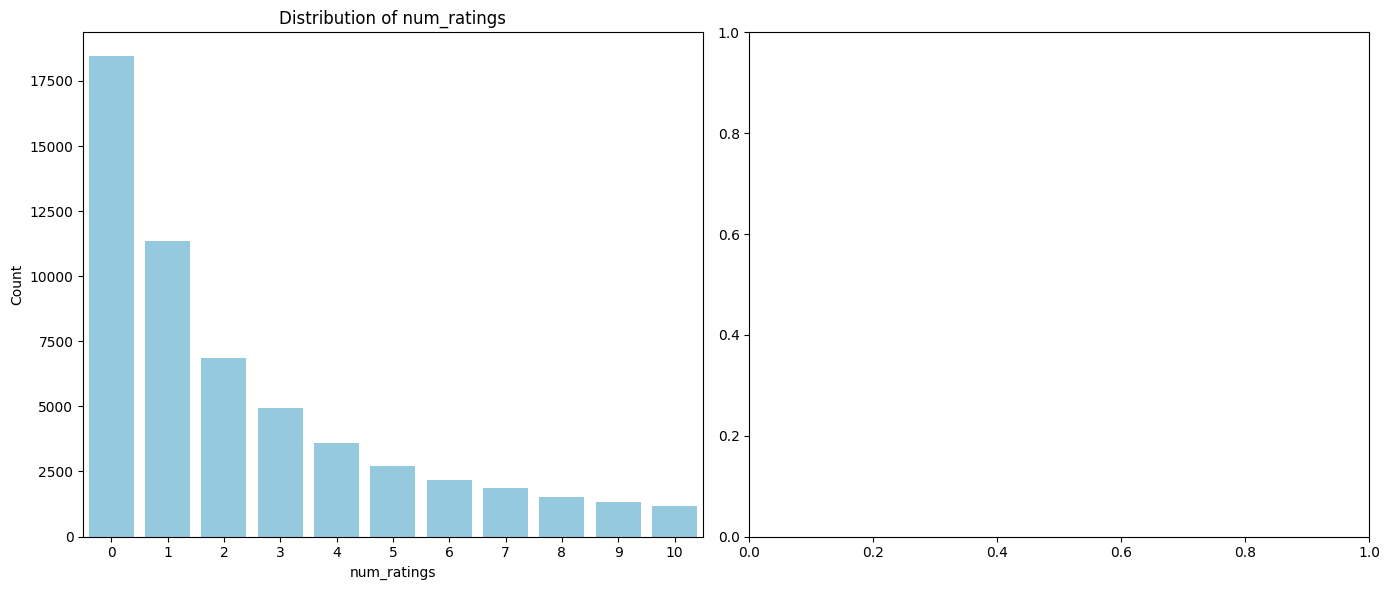

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.with_columns([
    pl.col("num_ratings").cast(pl.Int64, strict=False),
])
df = df.drop_nulls(subset=["num_ratings"])
print("--- Statistics ---")
print(df.select(["num_ratings"]).describe())

quantiles = df.select([
    pl.col("num_ratings").quantile(0.90).alias("90th %"),
    pl.col("num_ratings").quantile(0.95).alias("95th %"),
    pl.col("num_ratings").quantile(0.99).alias("99th %"),
    pl.col("num_ratings").max().alias("Absolute Max")
])
print("\n--- Percentiles for num_ratings ---")
print(quantiles)
print("\n--- Most Common num_ratings ---")
print(df["num_ratings"].value_counts().sort("count", descending=True).head(10))
pdf = df.select(["num_ratings"]).to_pandas()
_, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(data=pdf[pdf["num_ratings"] <= 10], x="num_ratings", ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of num_ratings')
axes[0].set_xlabel('num_ratings')
axes[0].set_ylabel('Count')

plt.tight_layout()
plt.show()